In [15]:
import numpy as np
import matplotlib.pyplot as plt

## Define Global Variables

Cell and grid information

In [16]:
nx = 60
ny = 60
Lx = 1
Ly = 1

xL = 0
xR = xL+Lx
yB = 0
yT = yB+Ly

n_p = nx*ny
nu = ny*(nx-1) + nx*(ny-1)
dx = Lx/nx
dy = Ly/ny

Time and simulation information

In [17]:
Ustar = 1
Re = 100

visc = Ustar*Lx/Re
CFL = 0.2 #dt = 0.005

maxStep = 20

dt = CFL*dx

endTime = maxStep*dt

Flow field and operator information

In [18]:
uBC_T = Ustar * np.ones(nx)    # 1-based, indexed i=2..nx
uBC_B = np.zeros(nx)
uBC_L = np.zeros(ny)           # 1-based, indexed j=1..ny
uBC_R = np.zeros(ny)

vBC_T = np.zeros(nx)           # 1-based, indexed i=1..nx
vBC_B = np.zeros(nx)
vBC_L = np.zeros(ny)           # 1-based, indexed j=2..ny
vBC_R = np.zeros(ny)

## Generate Grid and Cell Pointers

In [19]:
def Func_GenPointer(nx,ny):
    ip = np.zeros((nx, ny), dtype=int)
    iu = np.zeros((nx, ny), dtype=int)  # needs up to index nx+1
    iv = np.zeros((nx, ny), dtype=int)  # needs up to index ny+1

    count = 0
    for i in range(nx):          # 1..nx inclusive
        for j in range(ny):      # 1..ny inclusive
            ip[i,j] = count;  count += 1

    count = 0
    for i in range(1, nx):          # 2..nx inclusive (u-nodes)
        for j in range(ny):
            iu[i,j] = count;  count += 1

    # CRITICAL: v-indices continue from where u left off
    for i in range(nx):          # 1..nx inclusive (v-nodes)
        for j in range(1, ny):      # 2..ny inclusive
            iv[i,j] = count;  count += 1

    return [ip,iu,iv] 

def Func_GenGrid(xL,xR,nx,dx,yB,yT,ny,dy):
    xp = np.linspace(xL+dx/2,xR-dx/2,nx)
    yp = np.linspace(yB+dy/2,yT-dx/2,ny)
    
    xu = np.linspace(xL+dx/2,xR-dx/2,nx)
    yu = np.linspace(yB+dy/2,yT-dx/2,ny)
    
    xv = np.linspace(xL+dx/2,xR-dx/2,nx)
    yv = np.linspace(yB+dy/2,yT-dx/2,ny)
    
    return [xp,yp,xu,yu,xv,yv] 

In [20]:
[ip,iu,iv] = Func_GenPointer(nx,ny)
[xp,vp,xu,vu,xv,yv] = Func_GenGrid(xL,xR,nx,dx,yB,yT,ny,dy)

## Divergence Operator


In [21]:
# =====================================================================
#  DIVERGENCE  (homogeneous operator)
# =====================================================================
def Opt_D(x):
    sol = np.zeros(n_p)

    for i in range(nx):
        for j in range(ny):

            # ---- x-contribution (u-faces) ----
            if i == 0:
                du = x[iu[i+1, j]] / dx          # left wall: only right face stored
            elif i == nx-1:                       # right wall: only left face stored
                du = -x[iu[i, j]] / dx
            else:
                du = (x[iu[i+1, j]] - x[iu[i, j]]) / dx

            # ---- y-contribution (v-faces) ----
            if j == 0:
                dv = x[iv[i, j+1]] / dy          # bottom wall: only top face stored
            elif j == ny-1:                       # top wall: only bottom face stored
                dv = -x[iv[i, j]] / dy
            else:
                dv = (x[iv[i, j+1]] - x[iv[i, j]]) / dy

            sol[ip[i, j]] = du + dv

    return sol


# =====================================================================
#  DIVERGENCE BC VECTOR  (bcD)
# =====================================================================
def Div_BC():
    bcD = np.zeros(n_p)

    for i in range(nx):
        for j in range(ny):
            val = 0.0

            if i == 0:
                val += -uBC_L[j] / dx
            if i == nx-1:                         # right wall
                val += uBC_R[j] / dx
            if j == 0:
                val += -vBC_B[i] / dy
            if j == ny-1:                         # top wall
                val += vBC_T[i] / dy

            bcD[ip[i, j]] = val

    return bcD


## Gradient operator

In [22]:
# =====================================================================
#  GRADIENT OPERATOR  (G)
# =====================================================================
# Reference: Notes_AllOperators §2, Eq. (1)
#
#   (Gp)^u_{i,j} = (p_{i,j} - p_{i-1,j}) / dx    for i=2..nx, j=1..ny
#   (Gp)^v_{i,j} = (p_{i,j} - p_{i,j-1}) / dy    for i=1..nx, j=2..ny
#
# No boundary corrections needed — every u-node (i=2..nx) has pressure
# cells on both sides (i-1 and i), and likewise for v-nodes.
# =====================================================================


def Opt_G(x):
    """
    Gradient operator.
    Input:  x — pressure vector (length n_p, 1-based)
    Output: sol — velocity vector (length nu, 1-based)
    """
    sol = np.zeros(nu)
 
    # u-component of gradient
    for i in range(1, nx):
        for j in range(ny):
            sol[iu[i, j]] = (x[ip[i, j]] - x[ip[i - 1, j]]) / dx
 
    # v-component of gradient
    for i in range(nx):
        for j in range(1, ny):
            sol[iv[i, j]] = (x[ip[i, j]] - x[ip[i, j - 1]]) / dy
 
    return sol

## Laplace Operator

In [23]:
# =====================================================================
#  LAPLACIAN OPERATOR  (homogeneous)
# =====================================================================
def Laplace_x(x):
    sol = np.zeros(nu)

    # === U-component:  i = 1..nx-1,  j = 0..ny-1 ===
    for i in range(1, nx):
        for j in range(ny):

            # ---- x-direction stencil ----
            if i == 1:
                Lxx = (-2.0 * x[iu[i, j]] + x[iu[i+1, j]]) / dx**2   # left wall: drop ghost
            elif i == nx-1:                                              # right wall: drop ghost
                Lxx = (x[iu[i-1, j]] - 2.0 * x[iu[i, j]]) / dx**2
            else:
                Lxx = (x[iu[i-1, j]] - 2.0 * x[iu[i, j]] + x[iu[i+1, j]]) / dx**2

            # ---- y-direction stencil ----
            if j == 0:
                Lyy = (-3.0 * x[iu[i, j]] + x[iu[i, j+1]]) / dy**2   # bottom wall: ghost cell
            elif j == ny-1:                                              # top wall: ghost cell
                Lyy = (x[iu[i, j-1]] - 3.0 * x[iu[i, j]]) / dy**2
            else:
                Lyy = (x[iu[i, j-1]] - 2.0 * x[iu[i, j]] + x[iu[i, j+1]]) / dy**2

            sol[iu[i, j]] = Lxx + Lyy

    # === V-component:  i = 0..nx-1,  j = 1..ny-1 ===
    for i in range(nx):
        for j in range(1, ny):

            # ---- x-direction stencil ----
            if i == 0:
                Lxx = (-3.0 * x[iv[i, j]] + x[iv[i+1, j]]) / dx**2   # left wall: ghost cell
            elif i == nx-1:                                              # right wall: ghost cell
                Lxx = (x[iv[i-1, j]] - 3.0 * x[iv[i, j]]) / dx**2
            else:
                Lxx = (x[iv[i-1, j]] - 2.0 * x[iv[i, j]] + x[iv[i+1, j]]) / dx**2

            # ---- y-direction stencil ----
            if j == 1:
                Lyy = (-2.0 * x[iv[i, j]] + x[iv[i, j+1]]) / dy**2   # bottom wall: drop ghost
            elif j == ny-1:                                              # top wall: drop ghost
                Lyy = (x[iv[i, j-1]] - 2.0 * x[iv[i, j]]) / dy**2
            else:
                Lyy = (x[iv[i, j-1]] - 2.0 * x[iv[i, j]] + x[iv[i, j+1]]) / dy**2

            sol[iv[i, j]] = Lxx + Lyy

    return sol


# =====================================================================
#  LAPLACIAN BC VECTOR  (bcL)
# =====================================================================
def Laplace_BC():
    bcL = np.zeros(nu)

    # === U-component:  i = 1..nx-1,  j = 0..ny-1 ===
    for i in range(1, nx):
        for j in range(ny):
            val = 0.0

            if i == 1:                            # left wall: u-node ON wall
                val += uBC_L[j] / dx**2
            if i == nx-1:                         # right wall: u-node ON wall
                val += uBC_R[j] / dx**2
            if j == 0:                            # bottom wall: ghost cell → factor 2
                val += 2.0 * uBC_B[i] / dy**2
            if j == ny-1:                         # top wall: ghost cell → factor 2
                val += 2.0 * uBC_T[i] / dy**2

            bcL[iu[i, j]] = val

    # === V-component:  i = 0..nx-1,  j = 1..ny-1 ===
    for i in range(nx):
        for j in range(1, ny):
            val = 0.0

            if i == 0:                            # left wall: ghost cell → factor 2
                val += 2.0 * vBC_L[j] / dx**2
            if i == nx-1:                         # right wall: ghost cell → factor 2
                val += 2.0 * vBC_R[j] / dx**2
            if j == 1:                            # bottom wall: v-node ON wall
                val += vBC_B[i] / dy**2
            if j == ny-1:                         # top wall: v-node ON wall
                val += vBC_T[i] / dy**2

            bcL[iv[i, j]] = val

    return bcL


## Advection Operator

In [24]:
# ==== Advection operator ====
def Adv(Qi):
    '''
    advection operator (BC embedded): -nabla . (uu)
    input/output: velocity vector (length nu, 0-based)
    '''

    Qo = np.zeros(nu)

    # =========================================================
    # 1. U-Component  (u-nodes: i=1..nx-1, j=0..ny-1)
    # =========================================================

    # Inner domain (not touching any wall)
    for i in range(2, nx-1):
        for j in range(1, ny-1):
            Qo[iu[i,j]] = (- ( - ( Qi[iu[i-1,j]] + Qi[iu[i ,j]]  ) * ( Qi[iu[i-1,j]]   + Qi[iu[i,j]]   ) / 4
                               +   ( Qi[iu[i,j]]  + Qi[iu[i+1,j]] ) * ( Qi[iu[i,j]]     + Qi[iu[i+1,j]] ) / 4 ) / dx
                           - ( - ( Qi[iu[i,j-1]]  + Qi[iu[i,j]]   ) * ( Qi[iv[i-1,j]]   + Qi[iv[i,j]]   ) / 4
                               +   ( Qi[iu[i,j]]  + Qi[iu[i,j+1]] ) * ( Qi[iv[i-1,j+1]] + Qi[iv[i,j+1]] ) / 4 ) / dy)

    # --- Edges ---

    # bottom (j=0)
    j = 0
    for i in range(2, nx-1):
        Qo[iu[i,j]] = (- ( - ( Qi[iu[i-1,j]] + Qi[iu[i ,j]]  ) * ( Qi[iu[i-1,j]]   + Qi[iu[i ,j]]   ) / 4
                           +   ( Qi[iu[i ,j]] + Qi[iu[i+1,j]] ) * ( Qi[iu[i ,j]]    + Qi[iu[i+1,j]]  ) / 4 ) / dx
                       - ( -   ( uBC_B[i]                      ) * ( vBC_B[i-1]      + vBC_B[i]        ) / 2
                           +   ( Qi[iu[i ,j]] + Qi[iu[i ,j+1]] ) * ( Qi[iv[i-1,j+1]] + Qi[iv[i ,j+1]] ) / 4 ) / dy)

    # top (j=ny-1)
    j = ny-1
    for i in range(2, nx-1):
        Qo[iu[i,j]] = (- ( - ( Qi[iu[i-1,j]] + Qi[iu[i ,j]]  ) * ( Qi[iu[i-1,j]] + Qi[iu[i ,j]]  ) / 4
                           +   ( Qi[iu[i ,j]] + Qi[iu[i+1,j]] ) * ( Qi[iu[i ,j]]  + Qi[iu[i+1,j]] ) / 4 ) / dx
                       - ( - ( Qi[iu[i ,j-1]] + Qi[iu[i ,j]]  ) * ( Qi[iv[i-1,j]] + Qi[iv[i ,j]]  ) / 4
                           +   ( uBC_T[i]                      ) * ( vBC_T[i-1]    + vBC_T[i]       ) / 2 ) / dy)

    # left (i=1)
    i = 1
    for j in range(1, ny-1):
        Qo[iu[i,j]] = (- ( - ( uBC_L[j]       + Qi[iu[i ,j]]  ) * ( uBC_L[j]        + Qi[iu[i ,j]]   ) / 4
                           +   ( Qi[iu[i ,j]]  + Qi[iu[i+1,j]] ) * ( Qi[iu[i ,j]]    + Qi[iu[i+1,j]]  ) / 4 ) / dx
                       - ( - ( Qi[iu[i ,j-1]]  + Qi[iu[i ,j]]  ) * ( Qi[iv[i-1,j]]   + Qi[iv[i ,j]]   ) / 4
                           +   ( Qi[iu[i ,j]]  + Qi[iu[i ,j+1]] ) * ( Qi[iv[i-1,j+1]] + Qi[iv[i ,j+1]] ) / 4 ) / dy)

    # right (i=nx-1)
    i = nx-1
    for j in range(1, ny-1):
        Qo[iu[i,j]] = (- ( - ( Qi[iu[i-1,j]]  + Qi[iu[i ,j]]  ) * ( Qi[iu[i-1,j]]   + Qi[iu[i ,j]]   ) / 4
                           +   ( Qi[iu[i ,j]]  + uBC_R[j]       ) * ( Qi[iu[i ,j]]    + uBC_R[j]        ) / 4 ) / dx
                       - ( - ( Qi[iu[i ,j-1]]  + Qi[iu[i ,j]]  ) * ( Qi[iv[i-1,j]]   + Qi[iv[i ,j]]   ) / 4
                           +   ( Qi[iu[i ,j]]  + Qi[iu[i ,j+1]] ) * ( Qi[iv[i-1,j+1]] + Qi[iv[i ,j+1]] ) / 4 ) / dy)

    # --- Corners ---

    # bottom-left (i=1, j=0)
    i = 1; j = 0
    Qo[iu[i,j]] = (- ( - ( uBC_L[j]      + Qi[iu[i ,j]]  ) * ( uBC_L[j]        + Qi[iu[i ,j]]   ) / 4
                       +   ( Qi[iu[i ,j]] + Qi[iu[i+1,j]] ) * ( Qi[iu[i ,j]]    + Qi[iu[i+1,j]]  ) / 4 ) / dx
                   - ( -   ( uBC_B[i]                      ) * ( vBC_B[i-1]      + vBC_B[i]        ) / 2
                       +   ( Qi[iu[i ,j]] + Qi[iu[i ,j+1]] ) * ( Qi[iv[i-1,j+1]] + Qi[iv[i ,j+1]] ) / 4 ) / dy)

    # bottom-right (i=nx-1, j=0)
    i = nx-1; j = 0
    Qo[iu[i,j]] = (- ( - ( Qi[iu[i-1,j]] + Qi[iu[i ,j]]  ) * ( Qi[iu[i-1,j]]   + Qi[iu[i ,j]]   ) / 4
                       +   ( Qi[iu[i ,j]] + uBC_R[j]       ) * ( Qi[iu[i ,j]]    + uBC_R[j]        ) / 4 ) / dx
                   - ( -   ( uBC_B[i]                      ) * ( vBC_B[i-1]      + vBC_B[i]        ) / 2
                       +   ( Qi[iu[i ,j]] + Qi[iu[i ,j+1]] ) * ( Qi[iv[i-1,j+1]] + Qi[iv[i ,j+1]] ) / 4 ) / dy)

    # top-left (i=1, j=ny-1)
    i = 1; j = ny-1
    Qo[iu[i,j]] = (- ( - ( uBC_L[j]      + Qi[iu[i ,j]]  ) * ( uBC_L[j]      + Qi[iu[i ,j]]  ) / 4
                       +   ( Qi[iu[i ,j]] + Qi[iu[i+1,j]] ) * ( Qi[iu[i ,j]]  + Qi[iu[i+1,j]] ) / 4 ) / dx
                   - ( - ( Qi[iu[i ,j-1]] + Qi[iu[i ,j]]  ) * ( Qi[iv[i-1,j]] + Qi[iv[i ,j]]  ) / 4
                       +   ( uBC_T[i]                      ) * ( vBC_T[i-1]    + vBC_T[i]       ) / 2 ) / dy)

    # top-right (i=nx-1, j=ny-1)
    i = nx-1; j = ny-1
    Qo[iu[i,j]] = (- ( - ( Qi[iu[i-1,j]] + Qi[iu[i ,j]]  ) * ( Qi[iu[i-1,j]] + Qi[iu[i ,j]]  ) / 4
                       +   ( Qi[iu[i ,j]] + uBC_R[j]       ) * ( Qi[iu[i ,j]]  + uBC_R[j]       ) / 4 ) / dx
                   - ( - ( Qi[iu[i ,j-1]] + Qi[iu[i ,j]]  ) * ( Qi[iv[i-1,j]] + Qi[iv[i ,j]]  ) / 4
                       +   ( uBC_T[i]                      ) * ( vBC_T[i-1]    + vBC_T[i]       ) / 2 ) / dy)

    # =========================================================
    # 2. V-Component  (v-nodes: i=0..nx-1, j=1..ny-1)
    # =========================================================

    # Inner domain (not touching any wall)
    for i in range(1, nx-1):
        for j in range(2, ny-1):
            Qo[iv[i,j]] = (- ( - ( Qi[iu[i ,j-1]]  + Qi[iu[i ,j]]   ) * ( Qi[iv[i-1,j]] + Qi[iv[i ,j]]   ) / 4
                               +   ( Qi[iu[i+1,j-1]] + Qi[iu[i+1,j]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i+1,j]]  ) / 4 ) / dx
                           - ( - ( Qi[iv[i ,j-1]]  + Qi[iv[i ,j]]   ) * ( Qi[iv[i ,j-1]] + Qi[iv[i ,j]]   ) / 4
                               +   ( Qi[iv[i ,j]]   + Qi[iv[i ,j+1]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i ,j+1]]  ) / 4 ) / dy)

    # --- Edges ---

    # bottom (j=1)
    j = 1
    for i in range(1, nx-1):
        Qo[iv[i,j]] = (- ( - ( Qi[iu[i ,j-1]]  + Qi[iu[i ,j]]   ) * ( Qi[iv[i-1,j]] + Qi[iv[i ,j]]   ) / 4
                           +   ( Qi[iu[i+1,j-1]] + Qi[iu[i+1,j]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i+1,j]]  ) / 4 ) / dx
                       - ( - ( vBC_B[i]          + Qi[iv[i ,j]]   ) * ( vBC_B[i]       + Qi[iv[i ,j]]   ) / 4
                           +   ( Qi[iv[i ,j]]    + Qi[iv[i ,j+1]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i ,j+1]]  ) / 4 ) / dy)

    # top (j=ny-1)
    j = ny-1
    for i in range(1, nx-1):
        Qo[iv[i,j]] = (- ( - ( Qi[iu[i ,j-1]]  + Qi[iu[i ,j]]   ) * ( Qi[iv[i-1,j]] + Qi[iv[i ,j]]   ) / 4
                           +   ( Qi[iu[i+1,j-1]] + Qi[iu[i+1,j]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i+1,j]]  ) / 4 ) / dx
                       - ( - ( Qi[iv[i ,j-1]]  + Qi[iv[i ,j]]   ) * ( Qi[iv[i ,j-1]] + Qi[iv[i ,j]]   ) / 4
                           +   ( Qi[iv[i ,j]]   + vBC_T[i]        ) * ( Qi[iv[i ,j]]  + vBC_T[i]        ) / 4 ) / dy)

    # left (i=0)
    i = 0
    for j in range(2, ny-1):
        Qo[iv[i,j]] = (- ( - ( uBC_L[j-1]       + uBC_L[j]        ) * ( vBC_L[j]                        ) / 2
                           +   ( Qi[iu[i+1,j-1]]  + Qi[iu[i+1,j]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i+1,j]]  ) / 4 ) / dx
                       - ( - ( Qi[iv[i ,j-1]]   + Qi[iv[i ,j]]   ) * ( Qi[iv[i ,j-1]] + Qi[iv[i ,j]]   ) / 4
                           +   ( Qi[iv[i ,j]]    + Qi[iv[i ,j+1]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i ,j+1]]  ) / 4 ) / dy)

    # right (i=nx-1)
    i = nx-1
    for j in range(2, ny-1):
        Qo[iv[i,j]] = (- ( - ( Qi[iu[i ,j-1]]  + Qi[iu[i ,j]]   ) * ( Qi[iv[i-1,j]] + Qi[iv[i ,j]]   ) / 4
                           +   ( uBC_R[j-1]      + uBC_R[j]        ) * ( vBC_R[j]                        ) / 2 ) / dx
                       - ( - ( Qi[iv[i ,j-1]]  + Qi[iv[i ,j]]   ) * ( Qi[iv[i ,j-1]] + Qi[iv[i ,j]]   ) / 4
                           +   ( Qi[iv[i ,j]]   + Qi[iv[i ,j+1]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i ,j+1]]  ) / 4 ) / dy)

    # --- Corners ---

    # bottom-left (i=0, j=1)
    i = 0; j = 1
    Qo[iv[i,j]] = (- ( - ( uBC_L[j-1]      + uBC_L[j]        ) * ( vBC_L[j]                        ) / 2
                       +   ( Qi[iu[i+1,j-1]] + Qi[iu[i+1,j]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i+1,j]]  ) / 4 ) / dx
                   - ( - ( vBC_B[i]          + Qi[iv[i ,j]]   ) * ( vBC_B[i]       + Qi[iv[i ,j]]   ) / 4
                       +   ( Qi[iv[i ,j]]    + Qi[iv[i ,j+1]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i ,j+1]]  ) / 4 ) / dy)

    # bottom-right (i=nx-1, j=1)
    i = nx-1; j = 1
    Qo[iv[i,j]] = (- ( - ( Qi[iu[i ,j-1]]  + Qi[iu[i ,j]]   ) * ( Qi[iv[i-1,j]] + Qi[iv[i ,j]]   ) / 4
                       +   ( uBC_R[j-1]      + uBC_R[j]        ) * ( vBC_R[j]                        ) / 2 ) / dx
                   - ( - ( vBC_B[i]          + Qi[iv[i ,j]]   ) * ( vBC_B[i]       + Qi[iv[i ,j]]   ) / 4
                       +   ( Qi[iv[i ,j]]    + Qi[iv[i ,j+1]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i ,j+1]]  ) / 4 ) / dy)

    # top-left (i=0, j=ny-1)
    i = 0; j = ny-1
    Qo[iv[i,j]] = (- ( - ( uBC_L[j-1]      + uBC_L[j]        ) * ( vBC_L[j]                        ) / 2
                       +   ( Qi[iu[i+1,j-1]] + Qi[iu[i+1,j]]  ) * ( Qi[iv[i ,j]]  + Qi[iv[i+1,j]]  ) / 4 ) / dx
                   - ( - ( Qi[iv[i ,j-1]]  + Qi[iv[i ,j]]   ) * ( Qi[iv[i ,j-1]] + Qi[iv[i ,j]]   ) / 4
                       +   ( Qi[iv[i ,j]]   + vBC_T[i]        ) * ( Qi[iv[i ,j]]  + vBC_T[i]        ) / 4 ) / dy)

    # top-right (i=nx-1, j=ny-1)
    i = nx-1; j = ny-1
    Qo[iv[i,j]] = (- ( - ( Qi[iu[i ,j-1]]  + Qi[iu[i ,j]]   ) * ( Qi[iv[i-1,j]] + Qi[iv[i ,j]]   ) / 4
                       +   ( uBC_R[j-1]      + uBC_R[j]        ) * ( vBC_R[j]                        ) / 2 ) / dx
                   - ( - ( Qi[iv[i ,j-1]]  + Qi[iv[i ,j]]   ) * ( Qi[iv[i ,j-1]] + Qi[iv[i ,j]]   ) / 4
                       +   ( Qi[iv[i ,j]]   + vBC_T[i]        ) * ( Qi[iv[i ,j]]  + vBC_T[i]        ) / 4 ) / dy)

    return Qo


## Time Stepping Methods

In [25]:
def CGSolve(LHS, RHS, tol=1e-4, maxit=5000):
    u = np.zeros(RHS.shape)
    r = RHS #- LHS(u)
    p = r.copy()
    res0 = np.linalg.norm(r)
    # resvec = np.zeros(maxit)
    
    # Storage: list of (iteration, solution_2D,norm) tuples
    # Storage: list of (time, solution_2D,norm) tuples



    for step in range(1, maxit + 1):
        LHS_p = LHS(p)

        alpha = (r @ r) / (p @ LHS_p)
        r_new = r - alpha * LHS_p
        resvec = np.linalg.norm(r_new) / res0
        
        u = u + alpha * p

        if resvec < tol:
            return u
        
        beta = (r_new @ r_new) / (r @ r)
        p = r_new + beta * p
        r = r_new

    return u

## Simulation

### Prime Simulation

In [26]:
Opt_R = lambda x: x - (dt * visc / 2) * Laplace_x(x)
Opt_S = lambda x: x + (dt * visc / 2) * Laplace_x(x)
Opt_T = lambda x: Opt_D(Opt_S(Opt_G(x)))
Opt_C = lambda x: Opt_S(Opt_G(x))

BC_L = Laplace_BC()
BC_D = Div_BC()


### Run Simulation

In [27]:
def pin_pressure(x):
    y = x.copy()
    y[ip[0, 0]] = 0.0    # pin first pressure cell (0-based)
    return y

In [28]:
U    = np.zeros(nu)    # 0-based: no padding needed
Adv1 = np.zeros(nu)   # previous-step advection for Adams-Bashforth
time = 0
step = 0

while step <= maxStep:
    step += 1
    time  = step * dt
    Adv0  = Adv(U)

    ## Fractional step 1: implicit viscosity solve
    RHSU = Opt_S(U) + dt * (3*Adv0 - Adv1) / 2 + dt * visc * BC_L
    UF   = CGSolve(Opt_R, RHSU, 1E-8)

    ## Fractional step 2: pressure solve
    RHSP = (Opt_D(UF) + BC_D) / dt
    RHSP[ip[0, 0]] = 0.0                              # pin pressure (0-based)
    P    = CGSolve(lambda x: pin_pressure(Opt_T(x)), RHSP, 1E-8)

    ## Fractional step 3: pressure correction
    Unext = UF - dt * Opt_C(P)

    ## Advance
    Adv1 = Adv0
    diffNorm = (np.linalg.norm(Unext) - np.linalg.norm(U)) / np.linalg.norm(Unext)
    U = Unext
    print(f"Step {step:4d} | t = {time:.4f} | ||U|| = {np.linalg.norm(U):.6e} | dNorm = {diffNorm:.4e}")


Step    1 | t = 0.0033 | ||U|| = 1.503376e+00 | dNorm = 1.0000e+00
Step    2 | t = 0.0067 | ||U|| = 2.576737e+00 | dNorm = 4.1656e-01
Step    3 | t = 0.0100 | ||U|| = 3.366899e+00 | dNorm = 2.3469e-01
Step    4 | t = 0.0133 | ||U|| = 3.967376e+00 | dNorm = 1.5135e-01
Step    5 | t = 0.0167 | ||U|| = 4.438313e+00 | dNorm = 1.0611e-01
Step    6 | t = 0.0200 | ||U|| = 4.818852e+00 | dNorm = 7.8969e-02
Step    7 | t = 0.0233 | ||U|| = 5.134825e+00 | dNorm = 6.1535e-02
Step    8 | t = 0.0267 | ||U|| = 5.403554e+00 | dNorm = 4.9732e-02
Step    9 | t = 0.0300 | ||U|| = 5.636861e+00 | dNorm = 4.1390e-02
Step   10 | t = 0.0333 | ||U|| = 5.842970e+00 | dNorm = 3.5275e-02
Step   11 | t = 0.0367 | ||U|| = 6.027715e+00 | dNorm = 3.0649e-02
Step   12 | t = 0.0400 | ||U|| = 6.195318e+00 | dNorm = 2.7053e-02
Step   13 | t = 0.0433 | ||U|| = 6.348899e+00 | dNorm = 2.4190e-02
Step   14 | t = 0.0467 | ||U|| = 6.490807e+00 | dNorm = 2.1863e-02
Step   15 | t = 0.0500 | ||U|| = 6.622844e+00 | dNorm = 1.9937

## Plotting and Post-Processing

In [29]:
Uplot = U[iu]
Vplot = U[iv]
Pplot = P[ip]

Mag = np.sqrt(Uplot**2 + Vplot**2)

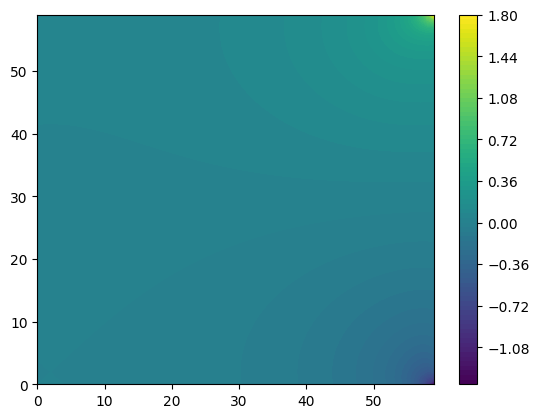

In [30]:
plt.contourf(Pplot,levels=100)
plt.colorbar()

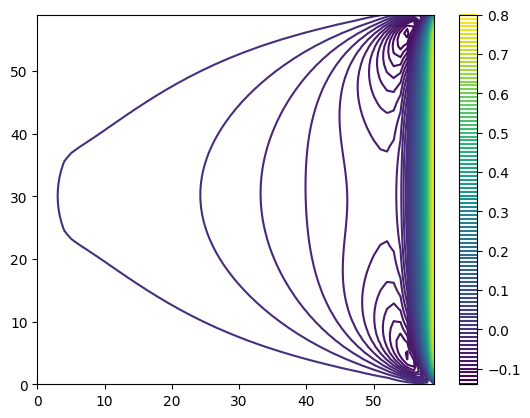

In [31]:
plt.contour(Uplot,levels=100)
plt.colorbar()

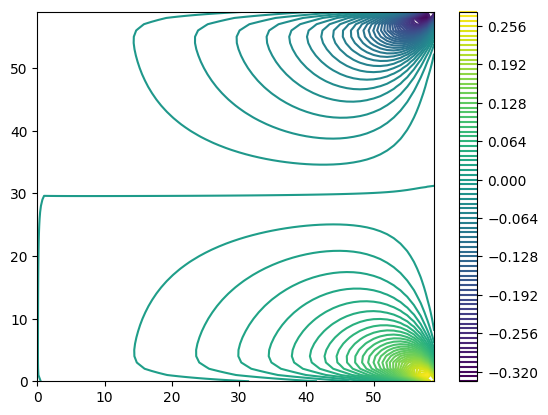

In [32]:
plt.contour(Vplot,levels=100)
plt.colorbar()

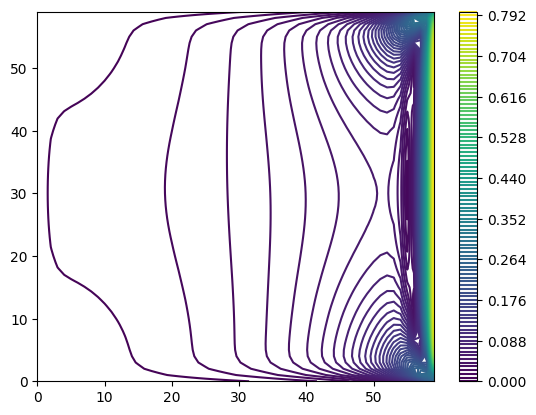

In [33]:
plt.contour(Mag,levels=100)
plt.colorbar()

# Testing

In [34]:
# =====================================================================
#  VERIFICATION HELPERS  (0-based indexing)
# =====================================================================
def run_basic_tests():
    """Quick sanity checks — call after setting up grid and BCs."""

    # ---- BC1: global mass conservation ----
    bcD = Div_BC()
    mass_balance = np.sum(bcD)          # no padding: sum all elements
    print(f"Test BC1  — sum(bcD) = {mass_balance:.2e}  (should be 0)")

    # ---- BC2: top-wall Laplace BC for u ----
    bcL = Laplace_BC()
    expected = 2.0 * Ustar / dy**2
    i_mid = max(1, nx // 2)            # any interior u-node column (i=1..nx-1)
    actual = bcL[iu[i_mid, ny-1]]      # top wall: j = ny-1
    print(f"Test BC2  — bcL at top wall = {actual:.6e},  "
          f"expected 2*U*/dy² = {expected:.6e}")

    # ---- L3: self-adjointness ----
    rng = np.random.default_rng(42)
    u_rand = rng.standard_normal(nu)
    v_rand = rng.standard_normal(nu)
    Lu = Laplace_x(u_rand)
    Lv = Laplace_x(v_rand)
    lhs = np.dot(u_rand, Lv)
    rhs = np.dot(v_rand, Lu)
    print(f"Test L3   — u^T L v = {lhs:.10e}")
    print(f"            v^T L u = {rhs:.10e}")
    print(f"            diff    = {abs(lhs - rhs):.2e}  (should be ~eps)")

    # ---- D3: adjoint property  u^T G p + p^T D u == 0 ----
    p_rand = rng.standard_normal(n_p)
    Gp = Opt_G(p_rand)
    Du = Opt_D(u_rand)
    lhs = np.dot(u_rand, Gp)
    rhs = np.dot(p_rand, Du)
    print(f"Test D3   — u^T G p = {lhs:.10e}")
    print(f"            p^T D u = {rhs:.10e}")
    print(f"            sum     = {lhs + rhs:.2e}  (should be ~eps)")


In [35]:
run_basic_tests()

Test BC1  — sum(bcD) = 0.00e+00  (should be 0)
Test BC2  — bcL at top wall = 7.200000e+03,  expected 2*U*/dy² = 7.200000e+03
Test L3   — u^T L v = 1.5165063428e+05
            v^T L u = 1.5165063428e+05
            diff    = 2.21e-09  (should be ~eps)
Test D3   — u^T G p = -3.0157334002e+03
            p^T D u = 3.0157334002e+03
            sum     = -1.36e-12  (should be ~eps)
